# 0.0. Setup

In [1]:
import os
import json
from pathlib import Path

import re
import pickle
import importlib
import numpy as np
import pandas as pd
import openpyxl as opxl
import matplotlib.pyplot as plt
from typing import Optional, Dict, Any, List

import geopandas as gpd
from shapely.geometry import Point
from difflib import SequenceMatcher
from sklearn.impute import SimpleImputer, KNNImputer

import networkx as nx
from scipy.spatial import cKDTree
from scipy.sparse import lil_matrix
from scipy.sparse.csgraph import dijkstra
from pyproj import Transformer

from matplotlib.colors import Normalize                                                                                                                            
import matplotlib.cm as cm

# None means 'no limit'
pd.set_option('display.max_columns', None)

PROJECT_DIR = Path.cwd().parent
if 'modules' not in os.listdir(Path.cwd()):
    os.chdir(PROJECT_DIR)

DATA_DIR = 'data'
DATA_PUBLIC_DIR = 'data/public'
DATA_PRIVATE_DIR = 'data/private'
DATA_PROCESSED_DIR = 'data/processed'
OUTPUT_DIR = 'output'

# 1.0. Load data

In [2]:
# Load school information table for joining geographic information of schools
fpath = 'output/processed_project_bukas_school_information.parquet'
sch_info = pd.read_parquet(fpath)
print(sch_info.shape)

(61442, 20)


In [3]:
display(sch_info.head(2))

,school_id,school_name,region,division,province,school_district,legislative_district,municipality,barangay,street_address,sector,school_management,annex_status,offers_es,offers_jhs,offers_shs,in_enr_2022_23,in_enr_2023_24,in_enr_2024_25,old_region
0,100001,Apaleng-Libtong ES,Region I,Ilocos Norte,ILOCOS NORTE,Bacarra I,1st District,BACARRA,LIBTONG,"Brgy. 21, Libtong, Bacarra, Ilocos Norte",Public,DepEd,Standalone School,True,False,False,True,True,True,Region I
1,100002,Bacarra CES,Region I,Ilocos Norte,ILOCOS NORTE,Bacarra I,1st District,BACARRA,SANTA RITA (POB.),Santa Rita,Public,DepEd,Standalone School,True,False,False,True,True,True,Region I


## 1.1. Road network

In [4]:
fname = 'road_network_ncr_region4a.geojson'
fpath = os.path.join(OUTPUT_DIR, fname)
rn = gpd.read_file(fpath)
print(rn.shape)
print(type(rn))

(371831, 6)
<class 'geopandas.geodataframe.GeoDataFrame'>


### Inspect

In [5]:
rn.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

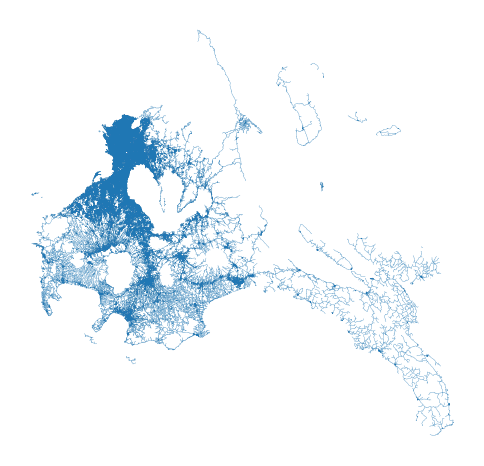

In [6]:
fig, ax = plt.subplots(figsize=(6,6))

rn.plot(linewidth=0.2, ax=ax)

ax.set_aspect("equal")
ax.axis("off")

plt.show()
plt.close()

## 1.2. Distance matrix

In [7]:
fpath = 'output/school_distance_matrix_long.parquet'
df_dist = pd.read_parquet(fpath)
print(df_dist.shape)

(1286202, 3)


In [8]:
display(df_dist.head())

,school_id_origin,school_id_destination,distance_m
0,107900,107902,5960.765137
1,107900,107905,2231.434814
2,107900,107906,795.638123
3,107900,107907,5616.100586
4,107900,107910,4144.646973


In [9]:
mask_both = (
    (df_dist['school_id_origin'].isin(df_dist['school_id_destination'].unique()))
)
df_dist[mask_both & (df_dist['school_id_origin'] == '107904')]

,school_id_origin,school_id_destination,distance_m
455,107904,107902,7449.179199
456,107904,107905,8610.046875
457,107904,107906,7174.250488
458,107904,107907,10292.816406
459,107904,107910,6200.922852
...,...,...,...
609,107904,408214,12777.447266
610,107904,424476,12849.989258
611,107904,424773,14513.875977
612,107904,424783,13944.820312


## 1.3. Shapefiles

In [10]:
fpath = 'output/consolidated_geodata_matched.gpkg'
df_shapefiles = gpd.read_file(fpath)
print(df_shapefiles.shape)

(42048, 23)


In [11]:
display(df_shapefiles.head(3))

,psgc_code,corr_code,name,adm4_en_psgc,adm1_pcode,adm2_pcode,adm3_pcode,adm4_pcode,adm1_psgc,adm2_psgc,adm3_psgc,adm4_psgc,adm1_en,adm2_en,adm3_en,adm4_en_shapes,geo_level,len_crs,area_crs,len_km,area_km2,is_spatially_matched,geometry
0,0102801001,12801001.0,Adams,Adams (Pob.),PH01,PH01028,PH0102801,PH0102801001,0100000000,0102800000,0102801000,0102801001,Region I (Ilocos Region),Ilocos Norte,Adams,Adams,Bgy,45997.0,111184551.0,45.0,111.0,False,"MULTIPOLYGON (((120.92068 18.51462, 120.94626 ..."
1,0102802001,12802001.0,Bani,Bani,PH01,PH01028,PH0102802,PH0102802001,0100000000,0102800000,0102802000,0102802001,Region I (Ilocos Region),Ilocos Norte,Bacarra,Bani,Bgy,5982.0,1761135.0,5.0,1.0,False,"MULTIPOLYGON (((120.61278 18.2759, 120.61282 1..."
2,0102802002,12802002.0,Buyon,Buyon,PH01,PH01028,PH0102802,PH0102802002,0100000000,0102800000,0102802000,0102802002,Region I (Ilocos Region),Ilocos Norte,Bacarra,Buyon,Bgy,9117.0,3875134.0,9.0,3.0,False,"MULTIPOLYGON (((120.62741 18.24638, 120.6337 1..."


### Filter & inspect

In [12]:
df_shapefiles.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

(5732, 23)


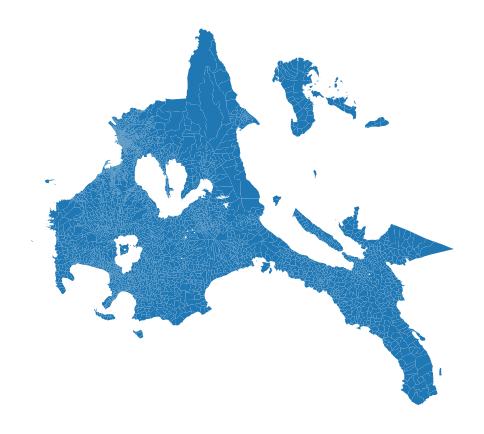

In [13]:
mask = (
    (df_shapefiles['adm1_en'].str.contains(r'calab|NCR', flags=re.IGNORECASE))
    | (df_shapefiles['adm2_en'].str.contains(r'NCR', flags=re.IGNORECASE))
)
df_shp = df_shapefiles.loc[mask].copy()
print(df_shp.shape)

fig, ax = plt.subplots(figsize=(6,6))

df_shp.plot(
    linewidth=0.2,
    ax=ax
)

ax.set_aspect("equal")
ax.axis("off")

plt.show()
plt.close()

In [14]:
# # Inspect NCR only
# mask = df_shapefiles['adm2_en'].str.contains(r'NCR', flags=re.IGNORECASE)
# df_shp = df_shapefiles.loc[mask].copy()
# print(df_shp.shape)

# fig, ax = plt.subplots(figsize=(16,16))

# df_shp.plot(
#     linewidth=0.2,
#     ax=ax
# )

# # A point that's supposedly out-of-bounds (?!)
# ax.scatter(
#     x=120.948531,
#     y=14.658431,
#     marker='o',
#     c='red'
# )

# ax.set_aspect("equal")
# ax.axis("off")

# plt.show()
# plt.close()

## 1.4. Coordinates

In [15]:
%%time
fname = 'all_schools_coordinates_ncr_region4a.parquet'
outpath = os.path.join(OUTPUT_DIR, fname)
sch_coords = pd.read_parquet(outpath)

# Join school information
sch_coords = sch_coords.merge(
    sch_info[['school_id','old_region','province']],
    on='school_id',
    how='left'
)

# Transform to geopandas (?)
sch_coords['geometry'] = sch_coords.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
sch_coords = gpd.GeoDataFrame(sch_coords, geometry='geometry', crs=4326)

print(sch_coords.shape)

(8331, 7)
CPU times: user 98.3 ms, sys: 2.46 ms, total: 101 ms
Wall time: 107 ms


In [16]:
sch_coords.isna().sum()

school_id     0
longitude     0
latitude      0
sector        0
old_region    0
province      0
geometry      0
dtype: int64

### Inpsect

In [17]:
sch_coords.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [18]:
type(sch_coords)

geopandas.geodataframe.GeoDataFrame

In [19]:
sch_coords['old_region'].unique()

array(['Region IV-A', 'NCR'], dtype=object)

In [20]:
sch_coords['province'].unique()

array(['CAVITE', 'BATANGAS', 'LAGUNA', 'QUEZON', 'RIZAL',
       'NCR SECOND DISTRICT', 'NCR THIRD DISTRICT',
       'MANILA, NCR, FIRST DISTRICT', 'NCR FOURTH DISTRICT'], dtype=object)

In [21]:
display(sch_coords.head())

,school_id,longitude,latitude,sector,old_region,province,geometry
0,107900,120.960226,14.283250,public,Region IV-A,CAVITE,POINT (120.96023 14.28325)
1,107901,120.935551,14.326691,public,Region IV-A,CAVITE,POINT (120.93555 14.32669)
2,107902,120.934790,14.326390,public,Region IV-A,CAVITE,POINT (120.93479 14.32639)
3,107903,120.943507,14.264903,public,Region IV-A,CAVITE,POINT (120.94351 14.2649)
4,107904,120.947710,14.275440,public,Region IV-A,CAVITE,POINT (120.94771 14.27544)


## 1.5. Student flow

In [22]:
fpath = 'output/grade_7_student_flow_table_sy2324.parquet'
flow = pd.read_parquet(fpath)
print(flow.shape)

(288328, 4)


In [23]:
display(flow.head())

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary
0,100000,300378,8.0,NaN
1,100000,300388,25.0,NaN
2,100000,305334,1.0,NaN
3,100000,500057,2.0,NaN
4,100001,300002,6.0,NaN


In [24]:
mask = (
    (flow['count_non_beneficiary'] == 0)
    | (flow['count_esc_beneficiary'] == 0)
)
flow[mask]

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary


# 2.0. Visualization
I need a way to verify if the values in my distance matrix makes sense. In the past, I would plot my public and private schools on a map to do the following:
1. Have a bird's eye view of all public and private schools on a plot containing the shape of NCR and Region IV-A;
2. Given a school ID, locate the school on a plot containing the shape of the province where it (the school) is located;
3. An extension of #2, see the school's nearby schools with edges -- like an actual graph network

## 2.1.

In [25]:
# =============================================================================                                                                                                    
# 2.2a. Classify School Roles Based on Student Flow                                                                                                                                
# =============================================================================                                                                                                    
                                                                                                                                                                                 
# Extract unique school IDs from origin and destination columns                                                                                                                    
origins = set(flow['school_id_origin'].astype(str).unique())                                                                                                                       
destinations = set(flow['school_id_destination'].astype(str).unique())                                                                                                             
                                                                                                                                                                                 
print(f"Unique origin schools: {len(origins):,}")                                                                                                                                  
print(f"Unique destination schools: {len(destinations):,}")                                                                                                                        
                                                                                                                                                                                 
# Classify schools by role                                                                                                                                                         
origin_only = origins - destinations                                                                                                                                               
destination_only = destinations - origins                                                                                                                                          
both = origins & destinations                                                                                                                                                      
                                                                                                                                                                                 
print(f"\nSchool Role Classification:")                                                                                                                                            
print(f"  Origin only (sends students, receives none): {len(origin_only):,}")                                                                                                      
print(f"  Destination only (receives students, sends none): {len(destination_only):,}")                                                                                            
print(f"  Both (sends and receives students): {len(both):,}")                                                                                                                      
print(f"  Total unique schools in flow data: {len(origins | destinations):,}")                                                                                                     

Unique origin schools: 47,179
Unique destination schools: 16,035

School Role Classification:
  Origin only (sends students, receives none): 41,693
  Destination only (receives students, sends none): 10,549
  Both (sends and receives students): 5,486
  Total unique schools in flow data: 57,728


In [26]:
# Create role mapping DataFrame                                                                                                                                                    
role_records = []                                                                                                                                                                  
                                                                                                                                                                                 
for school_id in origin_only:                                                                                                                                                      
  role_records.append({'school_id': school_id, 'flow_role': 'origin'})                                                                                                           
                                                                                                                                                                                 
for school_id in destination_only:                                                                                                                                                 
  role_records.append({'school_id': school_id, 'flow_role': 'destination'})                                                                                                      
                                                                                                                                                                                 
for school_id in both:                                                                                                                                                             
  role_records.append({'school_id': school_id, 'flow_role': 'both'})                                                                                                             
                                                                                                                                                                                 
school_roles = pd.DataFrame(role_records)                                                                                                                                          
school_roles['school_id'] = school_roles['school_id'].astype(str)                                                                                                                  
                                                                                                                                                                                 
print(f"\nRole mapping DataFrame:")                                                                                                                                                
print(f"  Shape: {school_roles.shape}")                                                                                                                                            
display(school_roles['flow_role'].value_counts())


Role mapping DataFrame:
  Shape: (57728, 2)


flow_role
origin         41693
destination    10549
both            5486
Name: count, dtype: int64

In [37]:
# Sanity check if flow_role tagging is correct
ess_cols = [
    'school_id','school_name', 'old_region','division',
    'offers_es','offers_jhs','offers_shs',
]
roles_info = school_roles.merge(
    sch_info[ess_cols],
    on='school_id',
    how='left'
)
display(roles_info.sample(5))

,school_id,flow_role,school_name,old_region,division,offers_es,offers_jhs,offers_shs
37655,112976,origin,Aniog ES,Region V,Camarines Sur,True,False,False
17111,105191,origin,Sto. Tomas ES,Region III,Nueva Ecija,True,False,False
3291,486546,origin,Brentwood Academy of Las Pinas,NCR,Las Piñas City,True,False,False
46047,315821,destination,Magsaysay NHS,Region XI,Davao De Oro,False,True,False
55357,400255,both,Divine Word Academy of Dagupan,Region I,Dagupan City,True,True,True


## 2.2.

In [39]:
# Configuration                                                                                                                                                                    
MAX_DISTANCE_M = 10_000  # 10km threshold                                                                                                                                             
                                                                                                                                                                                 
print(f"Filtering flow edges by distance...")                                                                                                                                      
print(f"  Distance threshold: {MAX_DISTANCE_M / 1000:.1f} km")                                                                                                                     
print(f"  Original flow edges: {len(flow):,}")                                                                                                                                     
                                                                                                                                                                                 
# Ensure consistent string types for joining                                                                                                                                       
flow_str = flow.copy()                                                                                                                                                             
flow_str['school_id_origin'] = flow_str['school_id_origin'].astype(str)                                                                                                            
flow_str['school_id_destination'] = flow_str['school_id_destination'].astype(str)                                                                                                  
                                                                                                                                                                                 
df_dist_str = df_dist.copy()                                                                                                                                                       
df_dist_str['school_id_origin'] = df_dist_str['school_id_origin'].astype(str)                                                                                                      
df_dist_str['school_id_destination'] = df_dist_str['school_id_destination'].astype(str)                                                                                            
                                                                                                                                                                                 
# Join flow with distance matrix                                                                                                                                                   
flow_with_dist = flow_str.merge(                                                                                                                                                   
  df_dist_str,                                                                                                                                                                   
  on=['school_id_origin', 'school_id_destination'],                                                                                                                              
  how='inner'  # Only keep flows that have a distance value                                                                                                                      
)                                                                                                                                                                                  
                                                                                                                                                                                 
print(f"\nAfter joining with distance matrix:")                                                                                                                                    
print(f"  Flows with distance data: {len(flow_with_dist):,}")                                                                                                                      
print(f"  Flows without distance (dropped): {len(flow_str) - len(flow_with_dist):,}")                                                                                              
                                                                                                                                                                                 
# Apply distance threshold                                                                                                                                                         
flow_filtered = flow_with_dist[flow_with_dist['distance_m'] <= MAX_DISTANCE_M].copy()                                                                                              
                                                                                                                                                                                 
print(f"\nAfter distance threshold ({MAX_DISTANCE_M / 1000:.1f} km):")                                                                                                             
print(f"  Flows within threshold: {len(flow_filtered):,}")                                                                                                                         
print(f"  Flows beyond threshold (dropped): {len(flow_with_dist) - len(flow_filtered):,}")                                                                                         
                                                                                                                                                                                 
# Compute total count for convenience                                                                                                                                              
flow_filtered['total_count'] = (                                                                                                                                                   
  flow_filtered['count_non_beneficiary'].fillna(0) +                                                                                                                             
  flow_filtered['count_esc_beneficiary'].fillna(0)                                                                                                                               
)                                                                                                                                                                                  
                                                                                                                                                                                 
# Summary statistics                                                                                                                                                               
print(f"\nFiltered flow summary:")                                                                                                                                                 
print(f"  Columns: {list(flow_filtered.columns)}")                                                                                                                                 
print(f"  Distance range: {flow_filtered['distance_m'].min():.0f}m - {flow_filtered['distance_m'].max():.0f}m")                                                                    
print(f"  Mean distance: {flow_filtered['distance_m'].mean():.0f}m")                                                                                                               
print(f"  Total students in filtered flows: {flow_filtered['total_count'].sum():,.0f}")                                                                                            

print(flow_filtered.shape)
display(flow_filtered.head())

Filtering flow edges by distance...
  Distance threshold: 10.0 km
  Original flow edges: 288,328

After joining with distance matrix:
  Flows with distance data: 10,889
  Flows without distance (dropped): 277,439

After distance threshold (10.0 km):
  Flows within threshold: 9,225
  Flows beyond threshold (dropped): 1,664

Filtered flow summary:
  Columns: ['school_id_origin', 'school_id_destination', 'count_non_beneficiary', 'count_esc_beneficiary', 'distance_m', 'total_count']
  Distance range: 0m - 9998m
  Mean distance: 4109m
  Total students in filtered flows: 106,736
(9225, 6)


,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary,distance_m,total_count
0,101701,301203,23.0,NaN,1984.276611,23.0
1,107201,307705,9.0,NaN,2531.785645,9.0
2,107202,307705,2.0,NaN,3593.090820,2.0
3,107202,401549,2.0,10.0,910.737732,12.0
4,107202,401552,NaN,1.0,3408.129883,1.0


In [60]:
flow_filtered[flow_filtered['school_id_destination'].str.contains(r'NaN|\s', flags=re.IGNORECASE)]

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary,distance_m,total_count


In [56]:
flow_filtered[flow_filtered['school_id_origin'].str.contains(r'na|\s', flags=re.IGNORECASE)]

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary,distance_m,total_count


In [67]:
# Sanity check if computed distances from distance matrix is an acceptable approximate
# This is checked manually in GMaps
origin_info = flow_filtered[['school_id_origin']].merge(
    sch_info[['school_id','school_name','old_region','division','sector']],
    left_on='school_id_origin',
    right_on='school_id',
    how='left'
)
origin_info.drop(columns=['school_id_origin','school_id'], inplace=True)

origin_info.columns = [col+'_origin' for col in origin_info.columns]
# display(origin_info)
print(origin_info.shape)

dest_info = flow_filtered[['school_id_destination']].merge(
    sch_info[['school_id','school_name','old_region','division','sector']],
    left_on='school_id_destination',
    right_on='school_id',
    how='left'
)
dest_info.drop(columns=['school_id_destination','school_id'], inplace=True)

dest_info.columns = [col+'_destination' for col in dest_info.columns]
# display(dest_info)
print(dest_info.shape)

tmp_flow = pd.concat([flow_filtered, origin_info, dest_info], axis=1)
tmp_flow.dropna(subset='school_id_origin', inplace=True)
print(tmp_flow.shape)

(9225, 4)
(9225, 4)
(9225, 14)


In [63]:
tmp_flow[tmp_flow['school_id_origin'].isna()]['total_count'].sum()

np.float64(0.0)

In [68]:
display(tmp_flow.sample(5))

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary,distance_m,total_count,school_name_origin,old_region_origin,division_origin,sector_origin,school_name_destination,old_region_destination,division_destination,sector_destination
491,107859,307801,2.0,NaN,9258.359375,2.0,San Nicolas Elementary School,Region IV-A,Bacoor City,Public,Bacoor National High School - Molino Main,Region IV-A,Bacoor City,Public
8817,424405,301180,1.0,NaN,4687.531738,1.0,"Lyngrove Christian Academy, Inc.",NCR,Pasig City,Private,Eusebio High School,NCR,Pasig City,Public
10369,485548,406585,2.0,NaN,892.579590,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9721,482796,305607,3.0,NaN,7502.817383,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7176,406621,305607,2.0,NaN,3905.924805,2.0,"St. Anthony of Makati Montessori, Inc.",NCR,Manila,Private,Saint Francis School,NCR,Manila,Private


In [76]:
# Another sample
display(tmp_flow.sample(5))

,school_id_origin,school_id_destination,count_non_beneficiary,count_esc_beneficiary,distance_m,total_count,school_name_origin,old_region_origin,division_origin,sector_origin,school_name_destination,old_region_destination,division_destination,sector_destination
5957,402362,402361,NaN,3.0,432.311493,3.0,Diliman Preparatory School - Annex,NCR,Quezon City,Private,"Colegio de San Bartolome de Novaliches, Inc.",NCR,Quezon City,Private
8538,409312,406787,NaN,1.0,3610.369629,1.0,Hope in Christ Christian Academy in Pasay Inc.,NCR,Pasay City,Private,St. Mary's Academy,NCR,Pasay City,Private
5136,136852,407210,NaN,1.0,4276.806152,1.0,Montessori Children's Workshop,Region IV-A,Binan City,Private,University of Perpetual Help System Laguna,Region IV-A,Binan City,Private
6888,406416,406413,NaN,9.0,1906.044067,9.0,"Army's Angels Integrated School, Inc.",NCR,Taguig City and Pateros,Private,Sen. Renato 'Compañero' Cayetano Memorial Scie...,NCR,Taguig City and Pateros,Public
8051,407251,407252,NaN,1.0,1046.245239,1.0,"Headstart Montessori School, Inc.",NCR,Quezon City,Private,St. Mary's College,NCR,Quezon City,Private


**Observations**
* The distance between San Nicolas Elementary School (107859) and Bacoor National High School - Molino Main (307801) is 1.7 kilometers only. My distance matrix for said schools shows a 9,258.359375 meter distance, which is very large difference.
* St. Anthony of Makati Montessori, Inc. (406621) and Saint Francis School (305607) in GMaps show a 950 meter distance while my distance matrix set it at 3,905.924805 meters. Again, a very large difference.
* Montessori Children's Workshop (136852) & University of Perpetual Help System Laguna (407210) in GMaps is just 2.8 kilometers. In my distance matrix, it's approx. 4.2 kilometers

## 2.3.